# Libraries

In [86]:
import matplotlib.pyplot as plt
# Do you want plot with latex font format? Use the cell bellow:
import matplotlib as mpl
import pandas as pd
import string
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })
import numpy as np
import pandas as pd

# Dataset upload or create

For simplicity we use a random variable concept to create a dataset.

In [87]:
df_v1 = pd.read_excel(
    "../data/figures/Figure_3.xlsx",
    sheet_name="Viga V1",
    header=1
)

df_v2 = pd.read_excel(
    "../data/figures/Figure_3.xlsx",
    sheet_name="Viga V2",
    header=1
)

y_v1 = df_v1['Momento (kNm)']
y_v2 = df_v2['Momento (kNm)']

# Crack width columns (duplicated names handled by pandas)
crack_cols = [
    'Abertura de Fissura (mm)',
    'Abertura de Fissura (mm).1',
    'Abertura de Fissura (mm).2'
]

# Chart

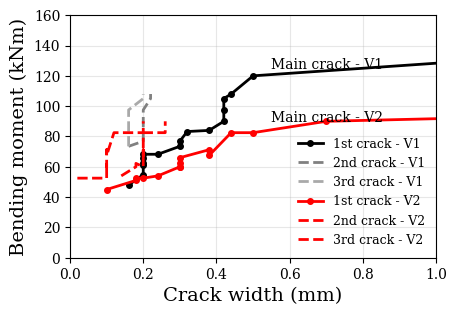

In [88]:
dpi = 600
name = 'figure_3a'

b_cm, h_cm = 12, 8
fig, ax = plt.subplots(figsize=(b_cm / 2.54, h_cm / 2.54))

ax.set_xlabel('Crack width (mm)', fontsize=14)
ax.set_ylabel('Bending moment (kNm)', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=10)

ax.set_xlim(0, 1.0)
ax.set_ylim(0, 160)

ax.grid(True, which='both', alpha=0.3)


styles = [
    dict(linestyle='-',  marker='o'),   # 1st crack
    dict(linestyle='--', marker=None),  # 2nd crack
    dict(linestyle='--', marker=None),  # 3rd crack
]


colors_v1 = ['black', 'gray', 'darkgray']
labels_v1 = ['1st crack - V1', '2nd crack - V1', '3rd crack - V1']

for col, style, color, label in zip(crack_cols, styles, colors_v1, labels_v1):
    x = df_v1[col]
    mask = x > 0

    ax.plot(
        x[mask],
        y_v1[mask],
        color=color,
        linewidth=2,
        markersize=4,
        label=label,
        **style
    )


labels_v2 = ['1st crack - V2', '2nd crack - V2', '3rd crack - V2']

for col, style, label in zip(crack_cols, styles, labels_v2):
    x = df_v2[col]
    mask = x > 0

    ax.plot(
        x[mask],
        y_v2[mask],
        color='red',
        linewidth=2,
        markersize=4,
        label=label,
        **style
    )


ax.text(0.55, 125, 'Main crack - V1', fontsize=10)
ax.text(0.55, 90,  'Main crack - V2', fontsize=10)


ax.legend(fontsize=9, frameon=False, loc='lower right')

fig.savefig(f'{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()

In [89]:
df_v3 = pd.read_excel(
    "../data/figures/Figure_3.xlsx",
    sheet_name="Viga V3",
    header=1
)

y_v3 = df_v3['Momento (kNm)']

crack_cols = [
    'Abertura de Fissura (mm)',
    'Abertura de Fissura (mm).1',
    'Abertura de Fissura (mm).2',
    'Abertura de Fissura (mm).3',
    'Abertura de Fissura (mm).4'
]

colors_v3 = ['black', 'red', 'blue', 'orange', 'green']
labels_v3 = [
    '1st crack - V3',
    '2nd crack - V3',
    '3rd crack - V3',
    '4th crack - V3',
    '5th crack - V3'
]

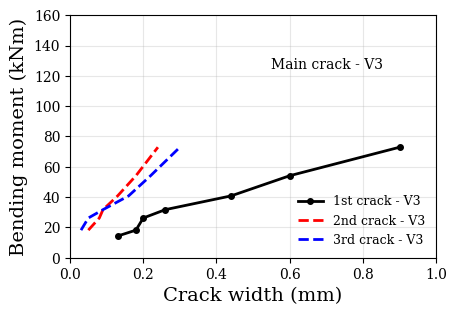

In [90]:
dpi = 600
name = 'figure_3b'

b_cm, h_cm = 12, 8
fig, ax = plt.subplots(figsize=(b_cm / 2.54, h_cm / 2.54))

ax.set_xlabel('Crack width (mm)', fontsize=14)
ax.set_ylabel('Bending moment (kNm)', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=10)

ax.set_xlim(0, 1.0)
ax.set_ylim(0, 160)

ax.grid(True, which='both', alpha=0.3)


for col, style, color, label in zip(crack_cols, styles, colors_v3, labels_v3):
    x = df_v3[col]
    mask = x > 0

    ax.plot(
        x[mask],
        y_v3[mask],
        color=color,
        linewidth=2,
        markersize=4,
        label=label,
        **style
    )



ax.text(0.55, 125, 'Main crack - V3', fontsize=10)

ax.legend(fontsize=9, frameon=False, loc='lower right')

fig.savefig(f'{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()

In [91]:
df = pd.read_excel(
    "../data/figures/Figure_4.xlsx",
    header=1
)

df = df.rename(columns={'Unnamed: 1': 'Experimental'})

x = df['Experimental']

y_cols = [
    'fib Model Code 2010',
    'fib Model Code 2020',
    'Eurocode 2',
    'NBR 6118',
    'GB 50010',
]

df_v12 = df.iloc[:-5]   # V1 + V2
df_v3  = df.iloc[-5:]   # V3 (last 5 rows)

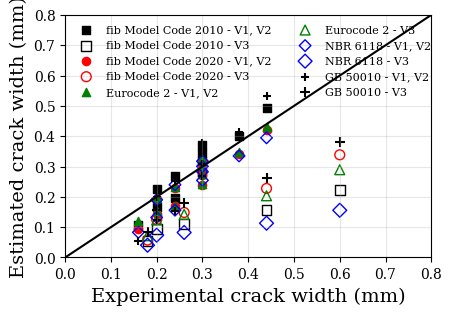

In [92]:
dpi = 600
b_cm, h_cm = 12, 8

fig, ax = plt.subplots(figsize=(b_cm / 2.54, h_cm / 2.54))

ax.set_xlabel('Experimental crack width (mm)', fontsize=14)
ax.set_ylabel('Estimated crack width (mm)', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=10)

ax.set_xlim(0, 0.8)
ax.set_ylim(0, 0.8)

ax.grid(True, which='both', alpha=0.3)


xx = np.linspace(0, 0.8, 100)
ax.plot(xx, xx, color='black', linewidth=1.5)


styles_v12 = {
    'fib Model Code 2010': dict(marker='s', facecolors='black', edgecolors='black'),
    'fib Model Code 2020': dict(marker='o', facecolors='red',   edgecolors='red'),
    'Eurocode 2':          dict(marker='^', facecolors='green', edgecolors='green'),
    'NBR 6118':            dict(marker='D', facecolors='none',  edgecolors='blue'),
    'GB 50010':            dict(marker='+', color='black'),
}

styles_v3 = {
    'fib Model Code 2010': dict(marker='s', facecolors='none', edgecolors='black'),
    'fib Model Code 2020': dict(marker='o', facecolors='none', edgecolors='red'),
    'Eurocode 2':          dict(marker='^', facecolors='none', edgecolors='green'),
    'NBR 6118':            dict(marker='D', facecolors='none', edgecolors='blue'),
    'GB 50010':            dict(marker='+', color='black'),
}


for col in y_cols:
    # V1 + V2
    ax.scatter(
        df_v12['Experimental'],
        df_v12[col],
        s=35,
        label=f'{col} - V1, V2',
        **styles_v12[col]
    )

    # V3
    ax.scatter(
        df_v3['Experimental'],
        df_v3[col],
        s=50,
        label=f'{col} - V3',
        **styles_v3[col]
    )


ax.legend(fontsize=8, frameon=False, loc='upper left', ncol=2)

fig.savefig('figura_4a.png', dpi=dpi, bbox_inches='tight') # Com tensao da armadura de ensaio
plt.show()

In [93]:
x = df['Experimental']

y_cols = [
    'fib Model Code 2010.1',
    'fib Model Code 2020.1',
    'Eurocode 2.1',
    'NBR 6118.1',
    'GB 50010.1',
]

df_v12 = df.iloc[:-5]   # V1 + V2
df_v3  = df.iloc[-5:]   # V3 (last 5 rows)



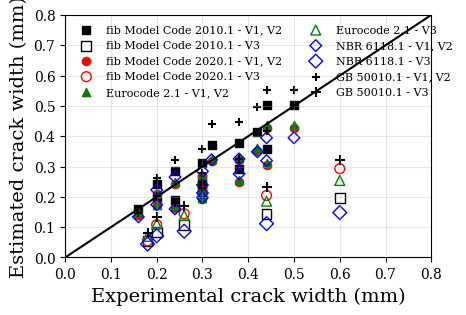

In [94]:
dpi = 600
b_cm, h_cm = 12, 8

fig, ax = plt.subplots(figsize=(b_cm / 2.54, h_cm / 2.54))

ax.set_xlabel('Experimental crack width (mm)', fontsize=14)
ax.set_ylabel('Estimated crack width (mm)', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=10)

ax.set_xlim(0, 0.8)
ax.set_ylim(0, 0.8)

ax.grid(True, which='both', alpha=0.3)


xx = np.linspace(0, 0.8, 100)
ax.plot(xx, xx, color='black', linewidth=1.5)


styles_v12 = {
    'fib Model Code 2010.1': dict(marker='s', facecolors='black', edgecolors='black'),
    'fib Model Code 2020.1': dict(marker='o', facecolors='red',   edgecolors='red'),
    'Eurocode 2.1':          dict(marker='^', facecolors='green', edgecolors='green'),
    'NBR 6118.1':            dict(marker='D', facecolors='none',  edgecolors='blue'),
    'GB 50010.1':            dict(marker='+', color='black'),
}

styles_v3 = {
    'fib Model Code 2010.1': dict(marker='s', facecolors='none', edgecolors='black'),
    'fib Model Code 2020.1': dict(marker='o', facecolors='none', edgecolors='red'),
    'Eurocode 2.1':          dict(marker='^', facecolors='none', edgecolors='green'),
    'NBR 6118.1':            dict(marker='D', facecolors='none', edgecolors='blue'),
    'GB 50010.1':            dict(marker='+', color='black'),
}


for col in y_cols:
    ax.scatter(
        df_v12['Experimental'],
        df_v12[col],
        s=35,
        label=f'{col} - V1, V2',
        **styles_v12[col]
    )

    ax.scatter(
        df_v3['Experimental'],
        df_v3[col],
        s=50,
        label=f'{col} - V3',
        **styles_v3[col]
    )


ax.legend(fontsize=8, frameon=False, loc='upper left', ncol=2)

fig.savefig('figura_4b.png', dpi=dpi, bbox_inches='tight') # Com tensao da armadura analitica
plt.show()

In [95]:
x = df['Experimental']

y_cols = [
    'Clark (1956)',
    'Leonhardt (1977)',
    'Desayi;Ganesan (1985)',
    'Oh; Kang (1987)',
]

df_v12 = df.iloc[:-5]   # V1 + V2
df_v3  = df.iloc[-5:]   # V3 (last 5 rows)



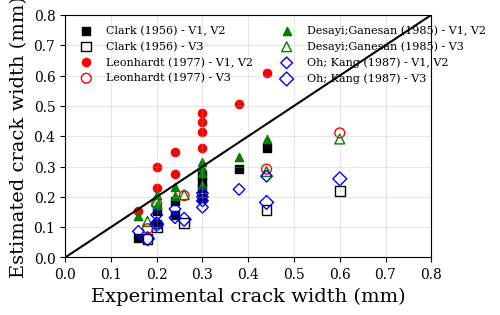

In [96]:
dpi = 600
b_cm, h_cm = 12, 8

fig, ax = plt.subplots(figsize=(b_cm / 2.54, h_cm / 2.54))

ax.set_xlabel('Experimental crack width (mm)', fontsize=14)
ax.set_ylabel('Estimated crack width (mm)', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=10)

ax.set_xlim(0, 0.8)
ax.set_ylim(0, 0.8)

ax.grid(True, which='both', alpha=0.3)


xx = np.linspace(0, 0.8, 100)
ax.plot(xx, xx, color='black', linewidth=1.5)


styles_v12 = {
    'Clark (1956)': dict(marker='s', facecolors='black', edgecolors='black'),
    'Leonhardt (1977)': dict(marker='o', facecolors='red',   edgecolors='red'),
    'Desayi;Ganesan (1985)':          dict(marker='^', facecolors='green', edgecolors='green'),
    'Oh; Kang (1987)':            dict(marker='D', facecolors='none',  edgecolors='blue'),
}

styles_v3 = {
    'Clark (1956)' : dict(marker='s', facecolors='none', edgecolors='black'),
    'Leonhardt (1977)' : dict(marker='o', facecolors='none', edgecolors='red'),
    'Desayi;Ganesan (1985)':          dict(marker='^', facecolors='none', edgecolors='green'),
    'Oh; Kang (1987)':            dict(marker='D', facecolors='none', edgecolors='blue'),
}


for col in y_cols:
    ax.scatter(
        df_v12['Experimental'],
        df_v12[col],
        s=35,
        label=f'{col} - V1, V2',
        **styles_v12[col]
    )

    ax.scatter(
        df_v3['Experimental'],
        df_v3[col],
        s=50,
        label=f'{col} - V3',
        **styles_v3[col]
    )


ax.legend(fontsize=8, frameon=False, loc='upper left', ncol=2)

fig.savefig('figura_4c.png', dpi=dpi, bbox_inches='tight') # Comparação das equações empíricas obtidas com a tensão na armadura medida no ensaio								
plt.show()

In [97]:
x = df['Experimental']

y_cols = [
    'Caldas (1997)',
    'Gergely e Lutz (1968)',
    'Yao et al (2021) modificado',
]

df_v12 = df.iloc[:-5]   
df_v3  = df.iloc[-5:]   

df.head()


,Unnamed: 0,Experimental,fib Model Code 2010,fib Model Code 2020,Eurocode 2,NBR 6118,GB 50010,fib Model Code 2010.1,fib Model Code 2020.1,Eurocode 2.1,NBR 6118.1,GB 50010.1,Clark (1956),Leonhardt (1977),Desayi;Ganesan (1985),Oh; Kang (1987),Caldas (1997),Gergely e Lutz (1968),Yao et al (2021) modificado
0,Viga V1 - Oliveira (2007),0.16,0.106010,0.093254,0.120309,0.082939,0.053247,0.160071,0.138680,0.148593,0.134038,0.147641,0.065459,0.153051,0.136774,0.086103,0.164329,0.138350,0.081186
1,NaN,0.20,0.166270,0.143889,0.151837,0.132104,0.125009,0.199877,0.172129,0.174292,0.174244,0.202616,0.110668,0.229735,0.172617,0.113687,0.217200,0.174605,0.122424
2,NaN,0.20,0.224438,0.192767,0.195708,0.190367,0.199089,0.242367,0.207832,0.211342,0.222970,0.261296,0.154308,0.298451,0.207215,0.140313,0.268235,0.209601,0.162231
3,NaN,0.24,0.267122,0.228634,0.232929,0.239874,0.253450,0.285304,0.243912,0.248783,0.265716,0.320594,0.186332,0.346926,0.232604,0.159852,0.305685,0.235282,0.191441
4,NaN,0.30,0.279258,0.238831,0.243511,0.254343,0.268906,0.313034,0.267213,0.272964,0.283721,0.358891,0.195437,0.360491,0.239822,0.165407,0.316333,0.242584,0.199746


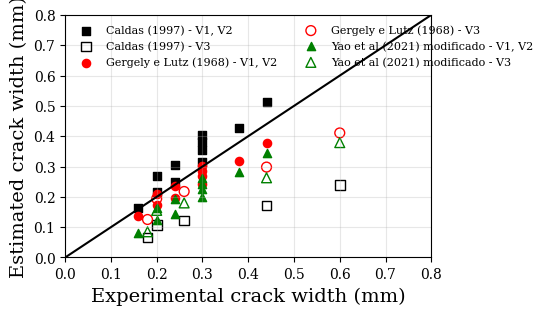

In [98]:
dpi = 600
b_cm, h_cm = 12, 8

fig, ax = plt.subplots(figsize=(b_cm / 2.54, h_cm / 2.54))

ax.set_xlabel('Experimental crack width (mm)', fontsize=14)
ax.set_ylabel('Estimated crack width (mm)', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=10)

ax.set_xlim(0, 0.8)
ax.set_ylim(0, 0.8)

ax.grid(True, which='both', alpha=0.3)


xx = np.linspace(0, 0.8, 100)
ax.plot(xx, xx, color='black', linewidth=1.5)


styles_v12 = {
    'Caldas (1997)': dict(marker='s', facecolors='black', edgecolors='black'),
    'Gergely e Lutz (1968)': dict(marker='o', facecolors='red',   edgecolors='red'),
    'Yao et al (2021) modificado':          dict(marker='^', facecolors='green', edgecolors='green'),
}

styles_v3 = {
    'Caldas (1997)' : dict(marker='s', facecolors='none', edgecolors='black'),
    'Gergely e Lutz (1968)' : dict(marker='o', facecolors='none', edgecolors='red'),
    'Yao et al (2021) modificado':  dict(marker='^', facecolors='none', edgecolors='green'),
}


for col in y_cols:
    # V1 + V2
    ax.scatter(
        df_v12['Experimental'],
        df_v12[col],
        s=35,
        label=f'{col} - V1, V2',
        **styles_v12[col]
    )

    # V3
    ax.scatter(
        df_v3['Experimental'],
        df_v3[col],
        s=50,
        label=f'{col} - V3',
        **styles_v3[col]
    )


ax.legend(fontsize=8, frameon=False, loc='upper left', ncol=2)

fig.savefig('figura_4d.png', dpi=dpi, bbox_inches='tight') # Comparação das equações empíricas obtidas com a tensão na armadura medida no ensaio								
plt.show()

In [99]:
df = pd.read_excel(
    "../data/figures/Figure_5.xlsx",
    sheet_name="Viga V1",
)

y = df['Momento (kNm)']
x = df['ss,exp (MPa)']

data = {
    'x': x,
    'y': y
}

df.head()

,Força (kN),Momento (kNm),"ss,exp (MPa)","ss,cal (MPa)"
0,63.5,47.625,230.79,285.048032
1,72.4,54.300,291.27,324.999646
2,81.9,61.425,349.65,367.644627
3,91.5,68.625,392.49,410.738503
4,97.7,73.275,404.67,438.569964


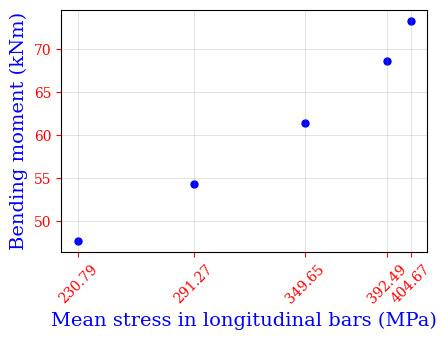

In [100]:
# Figure name and DPI
dpi = 600
name = 'figura_45'

b_cm = 12
h_cm = 8
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

label_x = 'Mean stress in longitudinal bars (MPa)'
label_y = 'Bending moment (kNm)'
size_label = 14
color_label = 'blue'
size_axis = 10
color_axis = 'red'

alpha_scatter = 1.0
color_scatter = 'blue'
size_scatter = 25

on_or_off = True
line_width_grid = 0.5
alpha_grid = 0.3
style_grid = '-'
color_grid = 'gray'

fig, ax = plt.subplots(figsize=(b_input, h_input))
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

ax.set_xticks(x)
ax.set_xticklabels([f"{v:.2f}" for v in x], rotation=45)

ax.grid(
    on_or_off,
    which='both',
    linestyle=style_grid,
    linewidth=line_width_grid,
    color=color_grid,
    alpha=alpha_grid
)

# Plot data
ax.scatter(
    x,
    y,
    alpha=alpha_scatter,
    color=color_scatter,
    s=size_scatter
)

fig.savefig(f'{name}.png', dpi=dpi, bbox_inches='tight')

# Show plot
plt.show()

In [101]:
import string

df = pd.read_excel(
    "../data/figures/Figure_7.xlsx",
    sheet_name="Dados",
    header=1
)

df = df.dropna(axis=1, how='all')
df = df.rename(columns={'Unnamed: 0': 'Experimental'})

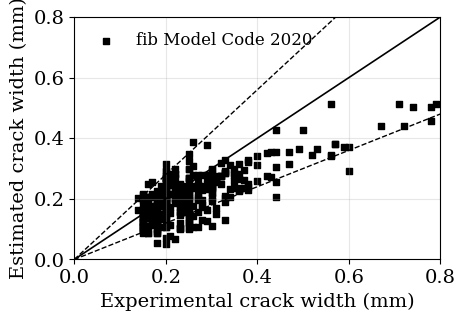

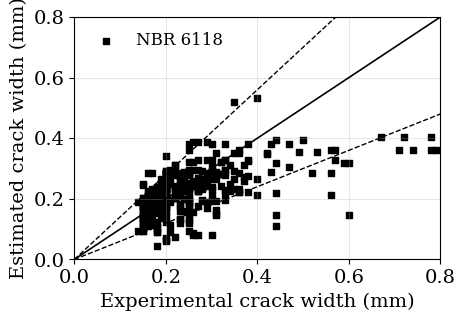

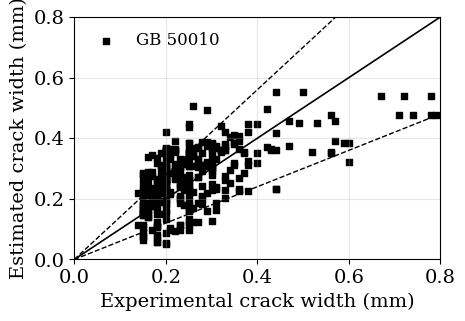

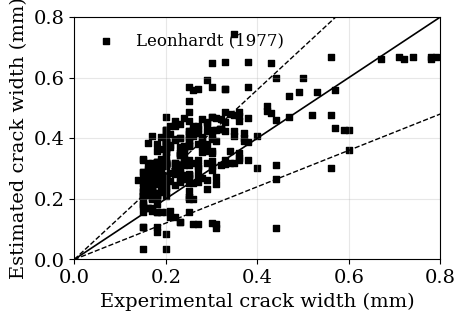

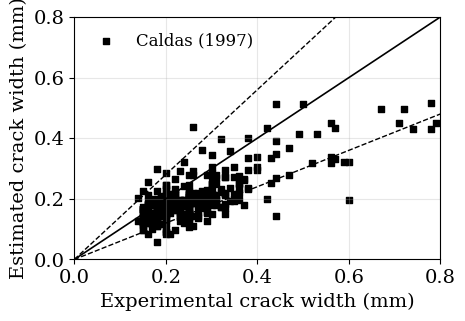

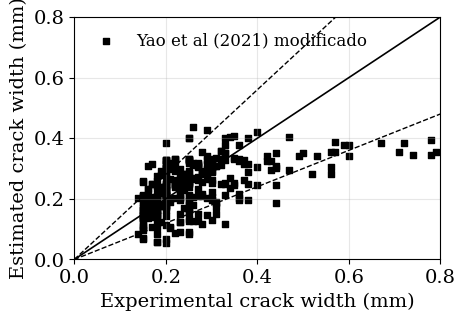

In [102]:
dpi = 600

b_cm = 12
h_cm = 8
b = b_cm / 2.54
h = h_cm / 2.54

size_label = 14
size_axis = 14
size_letter = 14

line_identity_width = 1.2
line_offset_width = 1.0
scatter_size = 20


x = df['Experimental']
x_line = np.linspace(0, 0.8, 200)

letters = list(string.ascii_lowercase)


for i, col in enumerate(df.columns):
    if col == 'Experimental':
        continue

    y = df[col]

    fig, ax = plt.subplots(figsize=(b, h))

    ax.scatter(
        x, y,
        s=scatter_size,
        color='black',
        marker='s',
        label=col
    )

    ax.plot(x_line, x_line, color='black', linewidth=line_identity_width)

    ax.plot(x_line, 1.4 * x_line, 'k--', linewidth=line_offset_width)
    ax.plot(x_line, 0.6 * x_line, 'k--', linewidth=line_offset_width)

    # Labels
    ax.set_xlabel('Experimental crack width (mm)', fontsize=size_label)
    ax.set_ylabel('Estimated crack width (mm)', fontsize=size_label)

    ax.set_xlim(0, 0.8)
    ax.set_ylim(0, 0.8)

    ax.tick_params(axis='both', labelsize=size_axis)
    ax.grid(True, alpha=0.3)

    ax.legend(frameon=False, fontsize=12, loc='upper left')


    fig.savefig(
        f'Figure_7_{letters[i-1]}.png',
        dpi=dpi,
        bbox_inches='tight'
    )

    plt.show()

In [103]:
df = pd.read_excel(
    "../data/figures/Figure_8.xlsx",
    sheet_name="Dados",
    header=1
)

df = df.dropna(axis=1, how='all')
df = df.rename(columns={'Unnamed: 0': 'Experimental'})

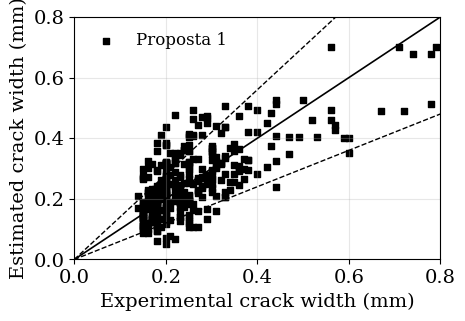

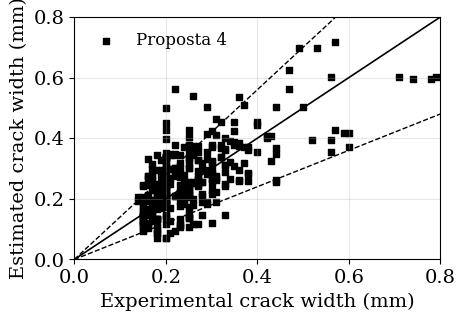

In [105]:
dpi = 600

b_cm = 12
h_cm = 8
b = b_cm / 2.54
h = h_cm / 2.54

size_label = 14
size_axis = 14
size_letter = 14

line_identity_width = 1.2
line_offset_width = 1.0
scatter_size = 20


x = df['Experimental']
x_line = np.linspace(0, 0.8, 200)

letters = list(string.ascii_lowercase)


for i, col in enumerate(df.columns):
    if col == 'Experimental':
        continue

    y = df[col]

    fig, ax = plt.subplots(figsize=(b, h))

    ax.scatter(
        x, y,
        s=scatter_size,
        color='black',
        marker='s',
        label=col
    )

    ax.plot(x_line, x_line, color='black', linewidth=line_identity_width)

    ax.plot(x_line, 1.4 * x_line, 'k--', linewidth=line_offset_width)
    ax.plot(x_line, 0.6 * x_line, 'k--', linewidth=line_offset_width)

    ax.set_xlabel('Experimental crack width (mm)', fontsize=size_label)
    ax.set_ylabel('Estimated crack width (mm)', fontsize=size_label)

    ax.set_xlim(0, 0.8)
    ax.set_ylim(0, 0.8)

    ax.tick_params(axis='both', labelsize=size_axis)
    ax.grid(True, alpha=0.3)

    ax.legend(frameon=False, fontsize=12, loc='upper left')


    fig.savefig(
        f'Figure_8_{letters[i-1]}.png',
        dpi=dpi,
        bbox_inches='tight'
    )

    plt.show()